# LMM Brain-Behavior Analysis: Pre-Decision Neural & Physiological Responses

**Purpose**: Use linear mixed models to ask three questions per modality — while controlling for subject-level differences via random intercepts:

1. **Behavior → Modality**: Which features are driven by trial-level task variables (ambiguity, EV difference, previous outcome, running invest rate, reaction time)?
2. **Modality → Decision**: Which features predict invest/keep *beyond* what task parameters already explain?
3. **Mediation**: Does ambiguity affect decisions *indirectly* through the top modality signal?

**Structure**:
- Section 1 — EEG (16 regional band-power features, 80 subjects)
- Section 2 — Pupil (13 features, 102 subjects)
- Section 3 — Gaze (16 features, 102 subjects)

All models use the **pre-decision window**. Behavioral predictors include reaction time (`decision_time`) — it is a behavioral variable, not treated separately.


In [31]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm, chi2
import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
np.random.seed(42)
Path('../../data/results/main/statistical_analyses').mkdir(parents=True, exist_ok=True)

In [32]:
# ── Load data ──────────────────────────────────────────────────────────
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)
merged_df   = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
gaze_cols   = feature_data['gaze_cols']

with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)
eeg_df   = eeg_data['eeg_features_df'].copy()
eeg_cols = eeg_data['feature_columns']

print(f'Behavioral/physio: {len(merged_df)} trials, {merged_df["subject_id"].nunique()} subjects')
print(f'EEG:               {len(eeg_df)} trials, {eeg_df["subject_id"].nunique()} subjects')
print(f'EEG features ({len(eeg_cols)}): {eeg_cols}')
print(f'Pupil features ({len([c for c in physio_cols if c.endswith("_pre")])}): {[c for c in physio_cols if c.endswith("_pre")]}')
print(f'Gaze features ({len(gaze_cols)}): {gaze_cols}')

Behavioral/physio: 12107 trials, 102 subjects
EEG:               10212 trials, 80 subjects
EEG features (16): ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Theta_Parietal', 'eeg_Theta_Occipital', 'eeg_Alpha_Frontal', 'eeg_Alpha_Central', 'eeg_Alpha_Parietal', 'eeg_Alpha_Occipital', 'eeg_Beta_Frontal', 'eeg_Beta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']
Pupil features (13): ['pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre', 'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre', 'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 'eye_asymmetry_std_pre']
Gaze features (20): ['gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_v

In [33]:
# ── Shared helpers & formulas ───────────────────────────────────────────
def zscore_cols(df, cols):
    df = df.copy()
    for c in cols:
        mu, sd = df[c].mean(), df[c].std()
        df[f'{c}_z'] = (df[c] - mu) / sd if sd > 0 else 0.0
    return df

def extract_coefs(fit, drop='Intercept'):
    df = pd.DataFrame({'coef': fit.fe_params, 'se': fit.bse_fe, 'pval': fit.pvalues})
    if drop and drop in df.index:
        df = df.drop(drop)
    df['ci_lo'] = df['coef'] - 1.96 * df['se']
    df['ci_hi'] = df['coef'] + 1.96 * df['se']
    df['sig']   = df['pval'] < 0.05
    return df

def scan_features(feature_cols, df, task_formula, task_ctrl, label='feature'):
    """
    For each feature column (already z-scored as {col}_z in df):
      direction A: ambiguity -> feature  (REML)
      direction B: feature -> outcome    (ML, controlling for task)
    Returns a DataFrame with betas, SEs, p-values for both directions.
    """
    results = []
    for col in feature_cols:
        zcol = f'{col}_z'
        if zcol not in df.columns:
            continue
        try:
            fit_a = smf.mixedlm(
                f'{zcol} ~ ambiguity_z + {task_ctrl}',
                data=df, groups=df['subject_id']
            ).fit(reml=True, disp=False)
            fit_b = smf.mixedlm(
                f'outcome ~ {zcol} + {task_formula}',
                data=df, groups=df['subject_id']
            ).fit(reml=False, disp=False)
            results.append({
                'feature':       col,
                'beta_beh':      fit_a.fe_params['ambiguity_z'],
                'se_beh':        fit_a.bse_fe['ambiguity_z'],
                'p_beh':         fit_a.pvalues['ambiguity_z'],
                'beta_dec':      fit_b.fe_params[zcol],
                'se_dec':        fit_b.bse_fe[zcol],
                'p_dec':         fit_b.pvalues[zcol],
            })
        except Exception:
            pass
    out = pd.DataFrame(results)
    out['sig_beh'] = out['p_beh'] < 0.05
    out['sig_dec'] = out['p_dec'] < 0.05
    return out

def plot_scan(scan_df, title, color_beh, color_dec, save_path):
    """Two-panel forest plot: behavior->feature and feature->decision."""
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(scan_df) * 0.4 + 1)))
    fig.suptitle(title + '\nStandardized β ± 95% CI  |  random intercept per subject',
                 fontsize=12, fontweight='bold')
    for ax, bcol, secol, sigcol, pcol, xlabel, color, panel_title in [
        (axes[0], 'beta_beh', 'se_beh', 'sig_beh', 'p_beh',
         'β (ambiguity → feature)',  color_beh, 'Behavior → Feature'),
        (axes[1], 'beta_dec', 'se_dec', 'sig_dec', 'p_dec',
         'β (feature → decision)',   color_dec, 'Feature → Decision'),
    ]:
        df_plot = scan_df.sort_values(bcol).reset_index(drop=True)
        short   = [c.replace('eeg_','').replace('_pre','').replace('gaze_','').replace('screen_','scr_')
                   for c in df_plot['feature']]
        bcolors = [color if s else '#BDBDBD' for s in df_plot[sigcol]]
        ax.barh(short, df_plot[bcol], color=bcolors, alpha=0.8, zorder=3)
        ax.errorbar(df_plot[bcol], short,
                    xerr=1.96*df_plot[secol], fmt='none',
                    color='#333333', capsize=3, linewidth=1.2, zorder=4)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(panel_title, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.4)
        for idx, row in df_plot.iterrows():
            if row[sigcol]:
                ax.text(row[bcol] + 1.96*row[secol] + 0.002, idx,
                        f'* p={row[pcol]:.3f}', va='center', fontsize=7.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def run_mediation(mediator_col, mediator_label, df_med, task_formula, task_ctrl):
    """Baron & Kenny mediation: ambiguity -> mediator -> decision. Sobel test."""
    zcol = f'{mediator_col}_z'
    # Path a: ambiguity -> mediator
    fit_a = smf.mixedlm(
        f'{zcol} ~ ambiguity_z + {task_ctrl}',
        data=df_med, groups=df_med['subject_id']
    ).fit(reml=True, disp=False)
    a_coef, a_se, a_p = fit_a.fe_params['ambiguity_z'], fit_a.bse_fe['ambiguity_z'], fit_a.pvalues['ambiguity_z']

    # Path c (total): ambiguity -> outcome
    fit_c = smf.mixedlm(
        f'outcome ~ ambiguity_z + {task_ctrl}',
        data=df_med, groups=df_med['subject_id']
    ).fit(reml=False, disp=False)
    c_total, c_total_p = fit_c.fe_params['ambiguity_z'], fit_c.pvalues['ambiguity_z']

    # Paths b + c': mediator -> outcome | ambiguity + task
    fit_bc = smf.mixedlm(
        f'outcome ~ {zcol} + ambiguity_z + {task_ctrl}',
        data=df_med, groups=df_med['subject_id']
    ).fit(reml=False, disp=False)
    b_coef, b_se, b_p   = fit_bc.fe_params[zcol], fit_bc.bse_fe[zcol], fit_bc.pvalues[zcol]
    c_prime, c_prime_p  = fit_bc.fe_params['ambiguity_z'], fit_bc.pvalues['ambiguity_z']

    indirect = a_coef * b_coef
    sobel_se = np.sqrt(b_coef**2 * a_se**2 + a_coef**2 * b_se**2)
    sobel_z  = indirect / sobel_se if sobel_se > 0 else 0.0
    sobel_p  = 2 * (1 - norm.cdf(abs(sobel_z)))
    prop_med = indirect / c_total if abs(c_total) > 1e-10 else np.nan

    print(f'MEDIATION: Ambiguity → {mediator_label} → Decision')
    print(f'  Path a (ambig → med):   β={a_coef:.4f}, p={a_p:.3e} {"*" if a_p<0.05 else "ns"}')
    print(f'  Path b (med → outcome): β={b_coef:.4f}, p={b_p:.3e} {"*" if b_p<0.05 else "ns"}')
    print(f'  Total effect (c):       β={c_total:.4f}, p={c_total_p:.3e}')
    print(f"  Direct effect (c'):     β={c_prime:.4f}, p={c_prime_p:.3e}")
    print(f'  Indirect (a×b):         {indirect:.5f}')
    print(f'  Sobel z={sobel_z:.3f},  p={sobel_p:.3e}')
    print(f'  Proportion mediated:    {prop_med*100:.1f}%')
    verdict = ('Partial mediation' if sobel_p<0.05 and c_prime_p<0.05
               else 'Full mediation' if sobel_p<0.05
               else 'No significant mediation')
    print(f'  → {verdict}')
    return dict(label=mediator_label, a=a_coef, a_p=a_p, b=b_coef, b_p=b_p,
                c=c_total, c_prime=c_prime, c_prime_p=c_prime_p,
                indirect=indirect, sobel_z=sobel_z, sobel_p=sobel_p,
                prop=prop_med, verdict=verdict)

def plot_mediation(med, color, save_path):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
    fig.suptitle(f'Mediation: Ambiguity → {med["label"]} → Decision', fontsize=12, fontweight='bold')
    node_kw = dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#1565C0', lw=2)
    med_kw  = dict(boxstyle='round,pad=0.5', facecolor='#F3E5F5', edgecolor=color, lw=2)
    ax.text(1.2, 3,   'Ambiguity',      ha='center', va='center', fontsize=11, fontweight='bold', bbox=node_kw)
    ax.text(5.0, 5.1, med['label'],     ha='center', va='center', fontsize=11, fontweight='bold', bbox=med_kw)
    ax.text(8.8, 3,   'Invest/Keep',    ha='center', va='center', fontsize=11, fontweight='bold', bbox=node_kw)
    ax.annotate('', xy=(3.9,4.7), xytext=(2.0,3.5), arrowprops=dict(arrowstyle='->',color=color,lw=2))
    ax.annotate('', xy=(7.9,3.5), xytext=(6.1,4.7), arrowprops=dict(arrowstyle='->',color=color,lw=2))
    ax.annotate('', xy=(7.9,2.8), xytext=(2.2,2.8), arrowprops=dict(arrowstyle='->',color='#1565C0',lw=2))
    ax.text(2.7, 4.45, f'a={med["a"]:.3f}{"*" if med["a_p"]<0.05 else " ns"}',
            fontsize=9, color=color, fontweight='bold')
    ax.text(7.0, 4.45, f'b={med["b"]:.3f}{"*" if med["b_p"]<0.05 else " ns"}',
            fontsize=9, color=color, fontweight='bold')
    c_prime_str = f'c′={med["c_prime"]:.3f}{"*" if med["c_prime_p"]<0.05 else " ns"}'
    ax.text(4.8, 2.3,
            f'c={med["c"]:.3f}*   {c_prime_str}',
            ha='center', fontsize=9, color='#1565C0', fontweight='bold')
    ax.text(5.0, 1.1,
            f'Indirect (a×b)={med["indirect"]:.4f}   Sobel z={med["sobel_z"]:.2f}, p={med["sobel_p"]:.3e}\n{med["verdict"]}',
            ha='center', fontsize=9, style='italic',
            bbox=dict(boxstyle='round', facecolor='#FFF9C4', edgecolor='#F57F17'))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Behavioral formula (reaction time is a behavioral variable)
task_formula = 'ambiguity_z + ev_difference_z + prev_outcome + running_invest_rate_z + decision_time_z'
task_ctrl    = 'ev_difference_z + prev_outcome + running_invest_rate_z + decision_time_z'

print('Helpers defined.')
print(f'Behavioral predictors: {task_formula}')

Helpers defined.
Behavioral predictors: ambiguity_z + ev_difference_z + prev_outcome + running_invest_rate_z + decision_time_z


---
# Section 1 — EEG

**Features**: 16 regional band-power features (4 frequency bands × 4 regions)
**Coverage**: 80 subjects, ~10,200 trials (pre-decision window)

Frequency bands: Delta (0.5–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz), Beta (13–30 Hz)
Regions: Frontal, Central, Parietal, Occipital

In [34]:
# Build EEG modeling dataframe
behavior_keep = ['subject_id', 'trial_id', 'outcome',
                 'ambiguity', 'ev_difference', 'decision_time',
                 'prev_outcome', 'running_invest_rate']

base_df = merged_df[behavior_keep].copy()
df_eeg  = base_df.merge(eeg_df[['trial_id'] + eeg_cols], on='trial_id', how='inner')
df_eeg  = df_eeg.dropna(subset=eeg_cols).reset_index(drop=True)
df_eeg  = zscore_cols(df_eeg, ['ambiguity', 'ev_difference', 'decision_time',
                                'running_invest_rate'] + eeg_cols)

print(f'EEG dataset: {len(df_eeg)} trials, {df_eeg["subject_id"].nunique()} subjects')

EEG dataset: 5437 trials, 80 subjects


## 1a — Behavior → EEG

**Question**: Which EEG features are driven by trial-level behavioral variables?

Each of the 16 features is regressed on the full behavioral formula with a subject random intercept.
The ambiguity β is highlighted — it tests whether task difficulty modulates pre-decision neural activity.

In [35]:
eeg_scan = scan_features(eeg_cols, df_eeg, task_formula, task_ctrl)

print(f'Behavior → EEG scan: {len(eeg_scan)} features')
print(f'  Sig ambiguity → EEG: {eeg_scan["sig_beh"].sum()} / {len(eeg_scan)}')
print()
print('Ambiguity effects (sorted by p):')
print(eeg_scan.sort_values('p_beh')[['feature','beta_beh','se_beh','p_beh','sig_beh']].to_string(index=False))

Behavior → EEG scan: 16 features
  Sig ambiguity → EEG: 0 / 16

Ambiguity effects (sorted by p):
            feature  beta_beh   se_beh    p_beh  sig_beh
eeg_Delta_Occipital  0.020858 0.013217 0.114542    False
 eeg_Delta_Parietal  0.019863 0.012858 0.122385    False
  eeg_Delta_Central  0.016303 0.012783 0.202200    False
   eeg_Beta_Central -0.015498 0.012881 0.228900    False
   eeg_Beta_Frontal -0.011029 0.011535 0.339007    False
  eeg_Theta_Frontal -0.008768 0.009419 0.351917    False
  eeg_Beta_Parietal -0.008097 0.010131 0.424168    False
 eeg_Alpha_Parietal  0.006064 0.008014 0.449203    False
  eeg_Delta_Frontal  0.009870 0.013130 0.452218    False
 eeg_Theta_Parietal  0.005896 0.007985 0.460290    False
  eeg_Alpha_Frontal -0.004713 0.008782 0.591529    False
eeg_Theta_Occipital  0.002665 0.007190 0.710920    False
  eeg_Theta_Central  0.002060 0.008540 0.809352    False
  eeg_Alpha_Central -0.001772 0.009177 0.846924    False
eeg_Alpha_Occipital  0.001344 0.007891 0.864735 

## 1b — EEG → Decision

**Question**: Which EEG features predict the invest/keep decision beyond behavioral variables?

Each feature is added to the full behavioral model and tested against the behavioral-only baseline.

EEG → Decision (sorted by p):
            feature  beta_dec   se_dec    p_dec  sig_dec
  eeg_Alpha_Frontal -0.025260 0.008680 0.003612     True
 eeg_Alpha_Parietal -0.025075 0.009185 0.006335     True
  eeg_Alpha_Central -0.021104 0.008270 0.010716     True
eeg_Alpha_Occipital -0.022242 0.009325 0.017069     True
  eeg_Theta_Frontal -0.016862 0.008119 0.037811     True
  eeg_Theta_Central -0.017997 0.008677 0.038075     True
  eeg_Beta_Parietal -0.015219 0.007678 0.047456     True
 eeg_Beta_Occipital -0.013319 0.008048 0.097929    False
   eeg_Beta_Frontal -0.011183 0.006831 0.101629    False
 eeg_Theta_Parietal -0.015312 0.009366 0.102087    False
   eeg_Beta_Central -0.008537 0.006185 0.167516    False
  eeg_Delta_Frontal -0.005854 0.006076 0.335238    False
 eeg_Delta_Parietal -0.004627 0.006193 0.455046    False
eeg_Theta_Occipital -0.007210 0.009992 0.470571    False
eeg_Delta_Occipital -0.004295 0.006037 0.476824    False
  eeg_Delta_Central -0.002776 0.006227 0.655766    False



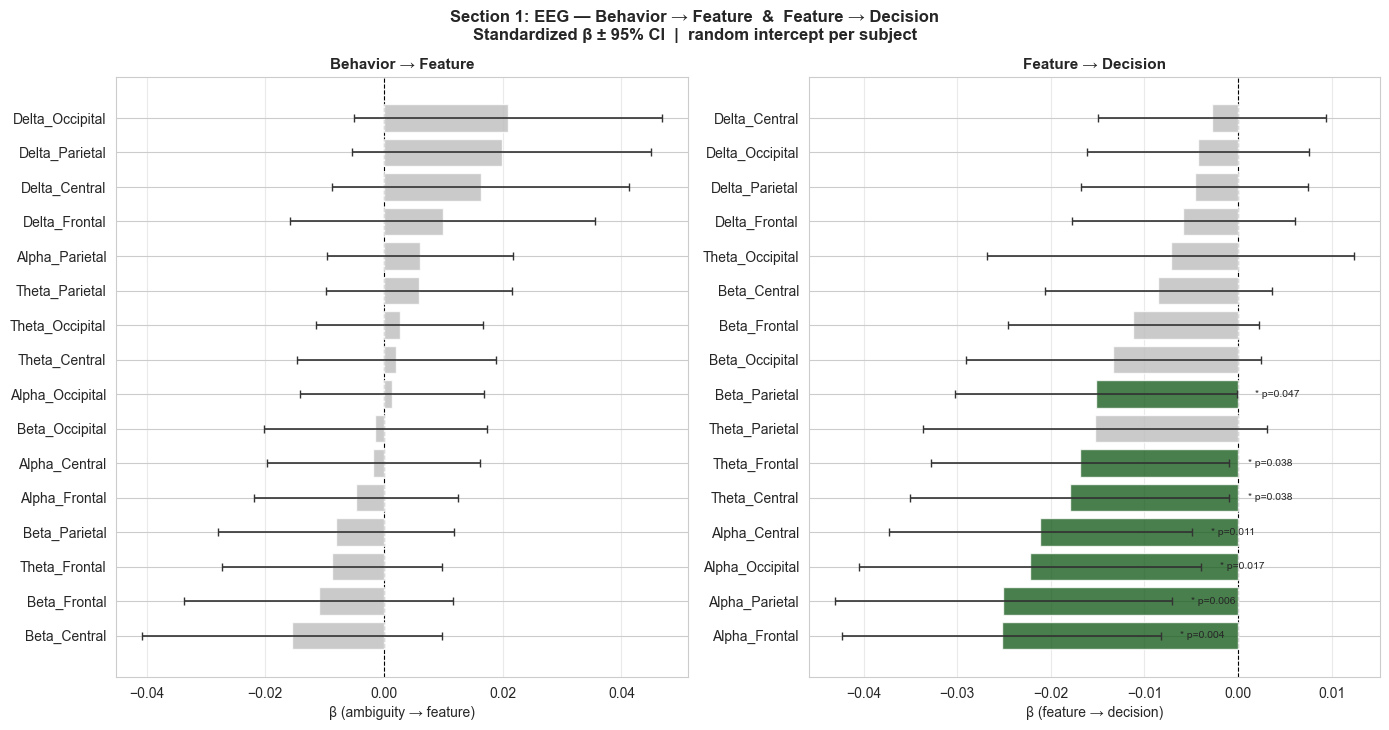

In [36]:
print('EEG → Decision (sorted by p):')
print(eeg_scan.sort_values('p_dec')[['feature','beta_dec','se_dec','p_dec','sig_dec']].to_string(index=False))
print(f'\n  Sig EEG → decision: {eeg_scan["sig_dec"].sum()} / {len(eeg_scan)}')
print(f'  Sig both directions: {(eeg_scan["sig_beh"] & eeg_scan["sig_dec"]).sum()} / {len(eeg_scan)}')

plot_scan(eeg_scan,
          title='Section 1: EEG — Behavior → Feature  &  Feature → Decision',
          color_beh='#4CAF50', color_dec='#1B5E20',
          save_path='../../data/results/main/statistical_analyses/lmm_eeg_scan.png')

## 1c — Mediation (EEG)

**Question**: Does ambiguity affect decisions *through* the top EEG signal?

We use the EEG feature most strongly driven by ambiguity (lowest p in 1a) as the candidate mediator.

Top ambiguity-driven EEG feature: eeg_Delta_Occipital
  ambiguity β=0.0209, p=1.145e-01

MEDIATION: Ambiguity → Delta_Occipital → Decision
  Path a (ambig → med):   β=0.0209, p=1.145e-01 ns
  Path b (med → outcome): β=-0.0043, p=4.768e-01 ns
  Total effect (c):       β=-0.1569, p=8.920e-158
  Direct effect (c'):     β=-0.1568, p=1.582e-157
  Indirect (a×b):         -0.00009
  Sobel z=-0.649,  p=5.166e-01
  Proportion mediated:    0.1%
  → No significant mediation


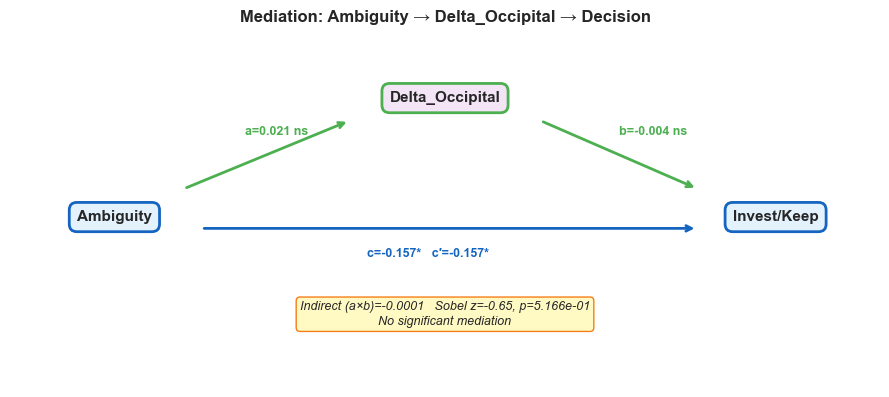

In [37]:
# Pick top ambiguity-driven EEG feature
top_eeg = eeg_scan.sort_values('p_beh').iloc[0]
print(f'Top ambiguity-driven EEG feature: {top_eeg["feature"]}')
print(f'  ambiguity β={top_eeg["beta_beh"]:.4f}, p={top_eeg["p_beh"]:.3e}')
print()

eeg_med = run_mediation(top_eeg['feature'], top_eeg['feature'].replace('eeg_',''),
                        df_eeg, task_formula, task_ctrl)
plot_mediation(eeg_med, color='#4CAF50',
               save_path='../../data/results/main/statistical_analyses/lmm_eeg_mediation.png')

---
# Section 2 — Pupil

**Features**: 13 pre-decision pupil features (mean, slope, velocity, dilation rate, etc.)
**Coverage**: 102 subjects, ~12,100 trials

In [38]:
# Build pupil modeling dataframe
pupil_cols = [c for c in physio_cols if c.endswith('_pre')]

df_pupil = merged_df[behavior_keep + pupil_cols].dropna(subset=pupil_cols).copy().reset_index(drop=True)
df_pupil = zscore_cols(df_pupil, ['ambiguity', 'ev_difference', 'decision_time',
                                   'running_invest_rate'] + pupil_cols)

print(f'Pupil dataset: {len(df_pupil)} trials, {df_pupil["subject_id"].nunique()} subjects')
print(f'Pupil features ({len(pupil_cols)}): {pupil_cols}')

Pupil dataset: 12107 trials, 102 subjects
Pupil features (13): ['pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre', 'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre', 'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 'eye_asymmetry_std_pre']


## 2a — Behavior → Pupil

**Question**: Which pupil dynamics are driven by trial-level behavioral variables?

In [39]:
pupil_scan = scan_features(pupil_cols, df_pupil, task_formula, task_ctrl)

print(f'Behavior → Pupil scan: {len(pupil_scan)} features')
print(f'  Sig ambiguity → pupil: {pupil_scan["sig_beh"].sum()} / {len(pupil_scan)}')
print()
print('Ambiguity effects (sorted by p):')
print(pupil_scan.sort_values('p_beh')[['feature','beta_beh','se_beh','p_beh','sig_beh']].to_string(index=False))

Behavior → Pupil scan: 13 features
  Sig ambiguity → pupil: 0 / 13

Ambiguity effects (sorted by p):
                        feature  beta_beh   se_beh    p_beh  sig_beh
                 pupil_mean_pre -0.013195 0.007839 0.092345    False
     pupil_acceleration_std_pre  0.010793 0.006914 0.118482    False
    pupil_max_dilation_rate_pre  0.008268 0.008315 0.320026    False
          pct_time_dilating_pre  0.007899 0.008443 0.349507    False
        pupil_velocity_mean_pre  0.005913 0.006381 0.354059    False
              eye_asymmetry_pre -0.005974 0.007063 0.397684    False
         num_dilation_peaks_pre -0.005955 0.007969 0.454927    False
pupil_max_constriction_rate_pre  0.005173 0.007297 0.478434    False
                  pupil_std_pre -0.004129 0.006737 0.539943    False
                pupil_slope_pre  0.004086 0.007061 0.562808    False
          eye_asymmetry_std_pre -0.003405 0.007894 0.666273    False
                   pupil_cv_pre -0.002586 0.009132 0.777067    False
  

## 2b — Pupil → Decision

**Question**: Which pupil features predict the invest/keep decision beyond behavioral variables?

Pupil → Decision (sorted by p):
                        feature  beta_dec   se_dec        p_dec  sig_dec
                pupil_slope_pre -0.040010 0.004888 2.723081e-16     True
          pct_time_dilating_pre -0.030489 0.004119 1.346774e-13     True
                  pupil_std_pre  0.034181 0.005089 1.866950e-11     True
        pupil_velocity_mean_pre  0.020406 0.005331 1.292757e-04     True
pupil_max_constriction_rate_pre  0.014329 0.004725 2.426573e-03     True
               time_to_peak_pre -0.012694 0.004187 2.430580e-03     True
     pupil_acceleration_std_pre  0.010356 0.004953 3.653038e-02     True
              eye_asymmetry_pre  0.010124 0.004850 3.683903e-02     True
                 pupil_mean_pre  0.008152 0.004422 6.525053e-02    False
         num_dilation_peaks_pre -0.007253 0.004365 9.657399e-02    False
          eye_asymmetry_std_pre  0.006932 0.004388 1.141213e-01    False
    pupil_max_dilation_rate_pre -0.002695 0.004184 5.195186e-01    False
                   

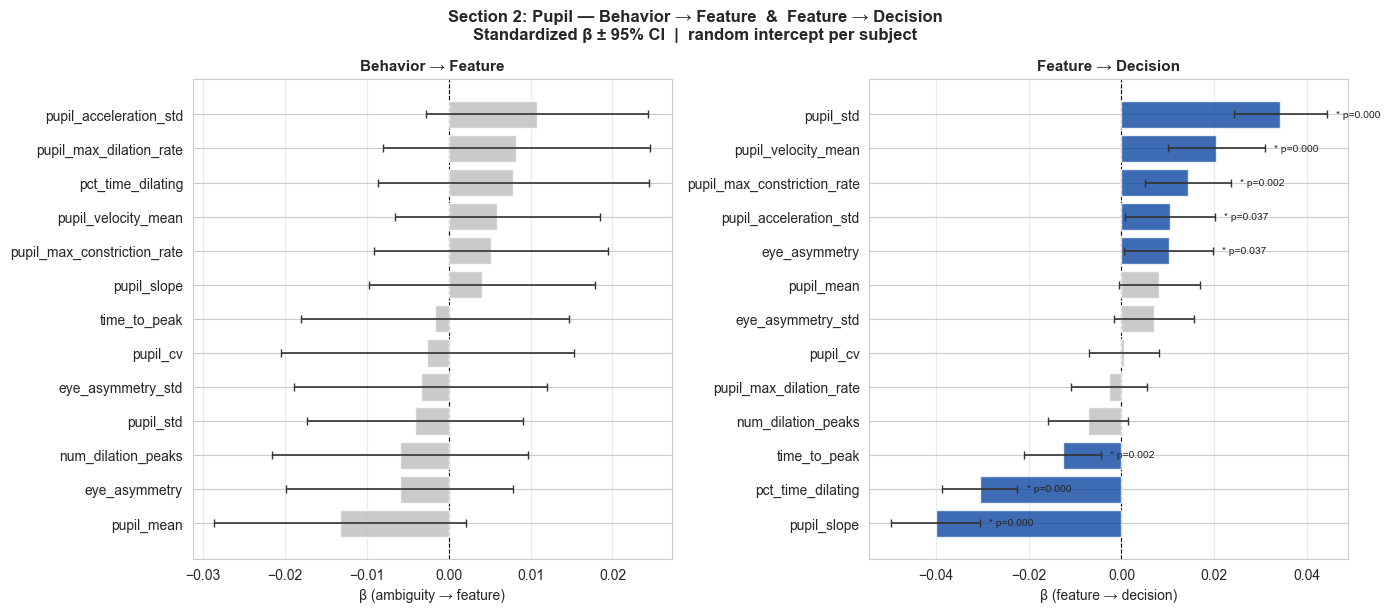

In [40]:
print('Pupil → Decision (sorted by p):')
print(pupil_scan.sort_values('p_dec')[['feature','beta_dec','se_dec','p_dec','sig_dec']].to_string(index=False))
print(f'\n  Sig pupil → decision: {pupil_scan["sig_dec"].sum()} / {len(pupil_scan)}')
print(f'  Sig both directions:  {(pupil_scan["sig_beh"] & pupil_scan["sig_dec"]).sum()} / {len(pupil_scan)}')

plot_scan(pupil_scan,
          title='Section 2: Pupil — Behavior → Feature  &  Feature → Decision',
          color_beh='#2196F3', color_dec='#0D47A1',
          save_path='../../data/results/main/statistical_analyses/lmm_pupil_scan.png')

## 2c — Mediation (Pupil)

**Question**: Does ambiguity affect decisions *through* the top pupil signal?

Top ambiguity-driven pupil feature: pupil_mean_pre
  ambiguity β=-0.0132, p=9.234e-02

MEDIATION: Ambiguity → pupil_mean → Decision
  Path a (ambig → med):   β=-0.0132, p=9.234e-02 ns
  Path b (med → outcome): β=0.0082, p=6.525e-02 ns
  Total effect (c):       β=-0.1396, p=6.627e-290
  Direct effect (c'):     β=-0.1395, p=1.144e-289
  Indirect (a×b):         -0.00011
  Sobel z=-1.243,  p=2.139e-01
  Proportion mediated:    0.1%
  → No significant mediation


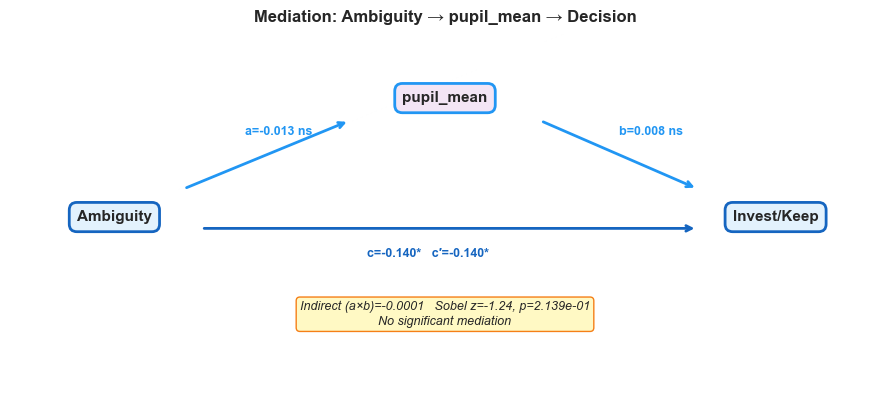

In [41]:
top_pupil = pupil_scan.sort_values('p_beh').iloc[0]
print(f'Top ambiguity-driven pupil feature: {top_pupil["feature"]}')
print(f'  ambiguity β={top_pupil["beta_beh"]:.4f}, p={top_pupil["p_beh"]:.3e}')
print()

pupil_med = run_mediation(top_pupil['feature'],
                          top_pupil['feature'].replace('_pre',''),
                          df_pupil, task_formula, task_ctrl)
plot_mediation(pupil_med, color='#2196F3',
               save_path='../../data/results/main/statistical_analyses/lmm_pupil_mediation.png')

---
# Section 3 — Gaze

**Features**: 16 pre-decision gaze features (position, spread, velocity, acceleration, dispersion)
**Coverage**: 102 subjects, ~12,100 trials

Excluded as near-constant across trials: `fixation_ratio`, `saccade_ratio`, `saccade_count`, `gaze_valid_pct`

In [42]:
# Build gaze modeling dataframe
gaze_model_cols = [c for c in gaze_cols if c not in
                   ['gaze_valid_pct', 'fixation_ratio', 'saccade_ratio', 'saccade_count']]

df_gaze = merged_df[behavior_keep + gaze_model_cols].dropna(subset=gaze_model_cols).copy().reset_index(drop=True)
df_gaze = zscore_cols(df_gaze, ['ambiguity', 'ev_difference', 'decision_time',
                                  'running_invest_rate'] + gaze_model_cols)

print(f'Gaze dataset: {len(df_gaze)} trials, {df_gaze["subject_id"].nunique()} subjects')
print(f'Gaze features ({len(gaze_model_cols)}): {gaze_model_cols}')

Gaze dataset: 12107 trials, 102 subjects
Gaze features (16): ['gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max', 'gaze_acceleration_mean', 'gaze_acceleration_std', 'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length']


## 3a — Behavior → Gaze

**Question**: Which gaze features are driven by trial-level behavioral variables?

In [43]:
gaze_scan = scan_features(gaze_model_cols, df_gaze, task_formula, task_ctrl)

print(f'Behavior → Gaze scan: {len(gaze_scan)} features')
print(f'  Sig ambiguity → gaze: {gaze_scan["sig_beh"].sum()} / {len(gaze_scan)}')
print()
print('Ambiguity effects (sorted by p):')
print(gaze_scan.sort_values('p_beh')[['feature','beta_beh','se_beh','p_beh','sig_beh']].to_string(index=False))

Behavior → Gaze scan: 16 features
  Sig ambiguity → gaze: 11 / 16

Ambiguity effects (sorted by p):
               feature  beta_beh   se_beh        p_beh  sig_beh
            gaze_y_std -0.154543 0.007586 2.972414e-92     True
           gaze_y_mean  0.068537 0.004260 3.086960e-58     True
            gaze_x_std  0.107002 0.006842 3.931210e-55     True
         screen_y_mean -0.018243 0.003266 2.331375e-08     True
          screen_x_std  0.044347 0.008058 3.728465e-08     True
     gaze_dispersion_x  0.031577 0.008038 8.547949e-05     True
     gaze_velocity_max  0.022189 0.008085 6.062403e-03     True
           gaze_x_mean -0.021121 0.008638 1.447779e-02     True
     gaze_velocity_std  0.017100 0.007767 2.768989e-02     True
         screen_x_mean  0.013698 0.006309 2.992490e-02     True
 gaze_acceleration_std  0.016019 0.007786 3.965361e-02     True
          screen_y_std -0.012595 0.007950 1.131539e-01    False
     gaze_dispersion_y  0.009661 0.008108 2.333930e-01    False
    

## 3b — Gaze → Decision

**Question**: Which gaze features predict the invest/keep decision beyond behavioral variables?

Gaze → Decision (sorted by p):
               feature  beta_dec   se_dec         p_dec  sig_dec
            gaze_x_std -0.110465 0.004935 5.577358e-111     True
          screen_x_std -0.022730 0.004304  1.284597e-07     True
            gaze_y_std  0.008868 0.004571  5.238513e-02    False
           gaze_y_mean -0.009180 0.007539  2.233717e-01    False
          screen_y_std  0.004314 0.004348  3.211728e-01    False
     gaze_dispersion_y  0.003791 0.004287  3.764703e-01    False
gaze_acceleration_mean  0.003742 0.004411  3.963091e-01    False
     gaze_dispersion_x -0.003617 0.004329  4.033879e-01    False
      gaze_path_length  0.002887 0.004293  5.013311e-01    False
    gaze_velocity_mean  0.002890 0.004484  5.192046e-01    False
         screen_y_mean  0.004633 0.009124  6.116274e-01    False
     gaze_velocity_std  0.001944 0.004435  6.610834e-01    False
         screen_x_mean -0.002032 0.005368  7.050689e-01    False
 gaze_acceleration_std  0.001593 0.004427  7.189824e-01    

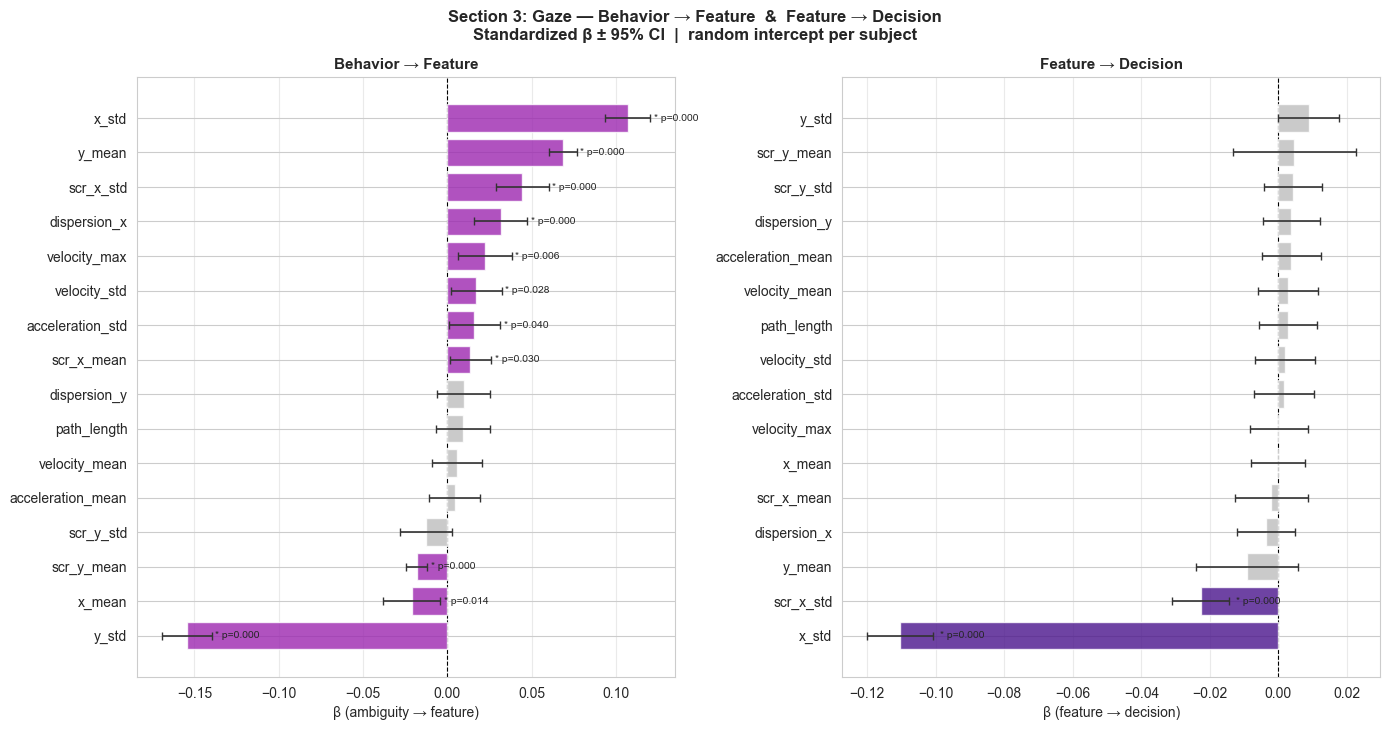

In [44]:
print('Gaze → Decision (sorted by p):')
print(gaze_scan.sort_values('p_dec')[['feature','beta_dec','se_dec','p_dec','sig_dec']].to_string(index=False))
print(f'\n  Sig gaze → decision:  {gaze_scan["sig_dec"].sum()} / {len(gaze_scan)}')
print(f'  Sig both directions:  {(gaze_scan["sig_beh"] & gaze_scan["sig_dec"]).sum()} / {len(gaze_scan)}')

plot_scan(gaze_scan,
          title='Section 3: Gaze — Behavior → Feature  &  Feature → Decision',
          color_beh='#9C27B0', color_dec='#4A148C',
          save_path='../../data/results/main/statistical_analyses/lmm_gaze_scan.png')

## 3c — Mediation (Gaze)

**Question**: Does ambiguity affect decisions *through* the top gaze signal?

Top ambiguity-driven gaze feature: gaze_y_std
  ambiguity β=-0.1545, p=2.972e-92

MEDIATION: Ambiguity → y_std → Decision
  Path a (ambig → med):   β=-0.1545, p=2.972e-92 *
  Path b (med → outcome): β=0.0089, p=5.239e-02 ns
  Total effect (c):       β=-0.1396, p=6.627e-290
  Direct effect (c'):     β=-0.1383, p=5.626e-275
  Indirect (a×b):         -0.00137
  Sobel z=-1.931,  p=5.346e-02
  Proportion mediated:    1.0%
  → No significant mediation


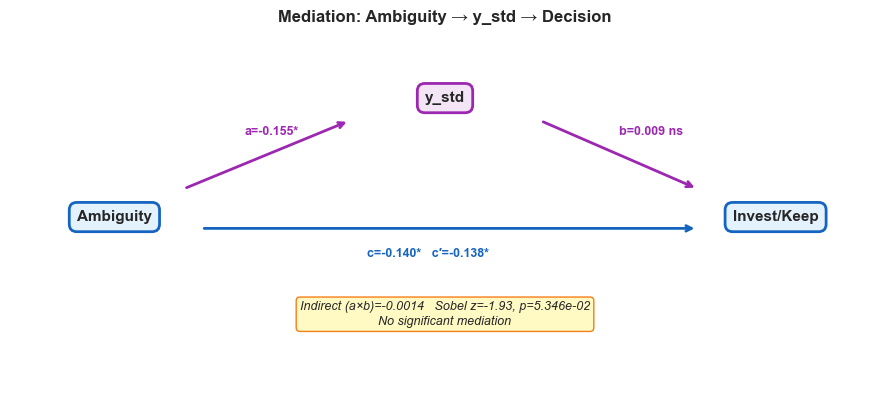

In [45]:
top_gaze = gaze_scan.sort_values('p_beh').iloc[0]
print(f'Top ambiguity-driven gaze feature: {top_gaze["feature"]}')
print(f'  ambiguity β={top_gaze["beta_beh"]:.4f}, p={top_gaze["p_beh"]:.3e}')
print()

gaze_med = run_mediation(top_gaze['feature'],
                         top_gaze['feature'].replace('gaze_','').replace('screen_','scr_'),
                         df_gaze, task_formula, task_ctrl)
plot_mediation(gaze_med, color='#9C27B0',
               save_path='../../data/results/main/statistical_analyses/lmm_gaze_mediation.png')

---
# Summary

In [46]:
print('='*70)
print('LMM BRAIN-BEHAVIOR SUMMARY')
print('='*70)
print(f'Behavioral predictors: ambiguity, EV difference, previous outcome,')
print(f'                       running invest rate, reaction time')
print()

for label, scan, med in [
    ('EEG   (16 features, 80 subj)', eeg_scan,   eeg_med),
    ('Pupil (13 features, 102 subj)', pupil_scan, pupil_med),
    ('Gaze  (16 features, 102 subj)', gaze_scan,  gaze_med),
]:
    print(f'{label}')
    print(f'  Behavior → feature:  {scan["sig_beh"].sum()} sig.')
    print(f'  Feature → decision:  {scan["sig_dec"].sum()} sig.')
    print(f'  Both directions:     {(scan["sig_beh"] & scan["sig_dec"]).sum()} sig.')
    print(f'  Mediation ({med["label"]}):')
    print(f'    Indirect a×b={med["indirect"]:.4f},  Sobel p={med["sobel_p"]:.3e}  → {med["verdict"]}')
    print()

LMM BRAIN-BEHAVIOR SUMMARY
Behavioral predictors: ambiguity, EV difference, previous outcome,
                       running invest rate, reaction time

EEG   (16 features, 80 subj)
  Behavior → feature:  0 sig.
  Feature → decision:  7 sig.
  Both directions:     0 sig.
  Mediation (Delta_Occipital):
    Indirect a×b=-0.0001,  Sobel p=5.166e-01  → No significant mediation

Pupil (13 features, 102 subj)
  Behavior → feature:  0 sig.
  Feature → decision:  8 sig.
  Both directions:     0 sig.
  Mediation (pupil_mean):
    Indirect a×b=-0.0001,  Sobel p=2.139e-01  → No significant mediation

Gaze  (16 features, 102 subj)
  Behavior → feature:  11 sig.
  Feature → decision:  2 sig.
  Both directions:     2 sig.
  Mediation (y_std):
    Indirect a×b=-0.0014,  Sobel p=5.346e-02  → No significant mediation

